In [8]:
%load_ext autoreload
%autoreload 2


import os
import logging
import pandas as pd
import numpy as np
import time
import torch
import wandb
import copy
from tqdm import tqdm


from src.constants import DEVICE
from src.utils.loss_func.get_loss_function import get_loss_function
from src.utils.optimizer.get_optimizer import get_optimizer
from src.utils.scheduler.get_scheduler import get_scheduler
from src.utils.move_batch_to_device import move_batch_to_device
from src.training.validate import validate
from src.models.tools.save_model import save_model, load_model
from src.training.utils.check_improvement import check_improvement

from src.hyper_opt.WandB_hpt import WandB_is_enabled, update_WandB_summary_table
from src.visualization.plot_model_inputs import plot_model_inputs
from src.evaluation.mainMetricHandler import mainMetricHandler
from src.utils.loss_func.calc_mixup_loss import calc_mixup_loss
from src.constants import MISSING_DATA_VALUE
from src.constants import DEVICE
from src.training.train import train
from src.training.validate import validate
from src.dataset.load_dataset import load_dataset, generate_K_fold_cross_validation_splits
from src.models.tools.get_classification_model import get_classification_model
from src.dataset.get_dataloader import make_dataloader   
from src.dataset.get_transforms import get_transforms
from src.utils.loss_func.get_loss_function import get_loss_function
from src.utils.saving.saving_predictions import concatenate_predictions, save_predictions
from src.utils.saving.create_results_directory import create_results_directory
from src.utils.list_dicts import append_to_list_dicts

from src.config_presets.tools.save_config import save_config
from src.hyper_opt.WandB_hpt import initialise_WandB_group, login, WandB_stop
from src.evaluation.mainMetricHandler import mainMetricHandler
from src.evaluation.total_evaluation import total_evaluation_current_fold
from src.evaluation.aggregate_metrics import aggregate_cross_validation_metrics
from src.evaluation.get_visualisations import get_visualizations



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from src.config_presets.tools.get_config import get_config

config = get_config('Multi_tox')




src/config_presets/Base_config.yaml
src/config_presets/Multi_tox.yaml


In [10]:
# load the data
df_train_val, df_test = load_dataset(config)
    
dataset_split_dict = generate_K_fold_cross_validation_splits(config, df_train_val)

# cap the number of iterations, if it is less than the number of k-splits to make
n_iterations = config['data']['kFolds']['n_iterations']

# get the data transforms
train_transforms, val_transforms = get_transforms(config)
# get the loss function
loss_function = get_loss_function(config)

metricHandler = mainMetricHandler(config)

import src.hyper_opt.WandB_hpt as WandB_hpt
# WandB
WandB_hpt.login(config)
WandB_hpt.initialise_WandB_group(config, project_name=config['general']['experiment_name'], groupName=config['general']['trialNumber'])


Removed ptns = 0

c:\Users\S.P.M. de Vette\.conda\envs\HNC_310\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
wandb: WARNING Calling wandb.login() after wandb.init() has no effect.



Train/Val dataset 872 (80.0%), Test dataset 218 (20.0%)


epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
train/AUC_Aspiration_M06,▄▃▂▃▅▁▃▁▄▄▆▃▅██▇█
train/AUC_Dysphagia_M06,▁▃▂▃▂▅▅▅▆▅▇▆██▇██
train/AUC_Sticky_M06,▂▃▁▅▃▃▅▃▄▅▅▅▆█▇█▇
train/AUC_Taste_M06,▁▃▂▃▂▄▅▅▅▆▆▅▇▇█▇█
train/AUC_Xerostomia_M06,▁▂▃▆▁▅▆▅▅▇▇▇▆█▇██
train/loss,█▄▅▄▅▄▃▃▃▄▂▃▂▁▂▁▂
train/loss_Aspiration_M06,▇▅▇█▆▇▅▅▅▆▄▅▃▂▂▁▃
train/loss_Dysphagia_M06,▂▆▂█▄▄▃▃▂▅▂▅▄▁▁▂▂
train/loss_Sticky_M06,▆█▆▇▄▆▄▅▅▆▅▇▅▁▂▃▃
train/loss_Taste_M06,▂▅▂▅█▁▃▃▁▃▁▃▅▁▂▂▂


In [4]:
train_data, val_data = dataset_split_dict[0]['train'], dataset_split_dict[0]['val']

train_loader, metadata = make_dataloader(config, train_data, train_transforms, validation_mode=False)
val_loader, _ = make_dataloader(config, val_data, val_transforms, validation_mode=True)



In [ ]:
from gradNorm import GradNorm

def GradNorm_train(config, model, loss_function, train_loader, val_loader, metricHandler):
    """
    Train the model.
    :param config:
    :param train_data:
    :param val_data:
    :return: Model
    """

    # config run information
    show_pbar = config['training']['show_progress_bar']

    mixup_is_enabled = config['data']['augmentation']['mixup']['isEnabled']

    # Get the names of the end-points being evaluated 
    labels = config['columns']['labels']

    # Get loss function, optimizer, and scheduler
    loss_function = get_loss_function(config)
    optimizer = get_optimizer(config, model)
    if config['training']['scheduler']['name'] is not False:
        scheduler = get_scheduler(config, optimizer)

    # get the main metric with which to evaluate the training loop (e.g. AUC)
    #metricHandler = mainMetricHandler(config)
    metric_name = metricHandler.metric_name

    # Initialize the best model and lowest validation loss
    best_model_state_dict = None
    if(config['training']['stopping_criteria'] == "loss"):
        print("Optimizing based on loss")
        best_value = np.inf
    else:
        best_value = 0
        
    patience_counter = 0
    

    sigmoid_act = torch.nn.Sigmoid()

    iters = 0
    lr2 = 0.001
    layer = model.output_head.linear_layers.shared_fc_layers
    log = True
    alpha = 1
    log_weights = []
    log_loss = []



    # Training loop
    logging.info('Starting training loop')
    for epoch_num in range(1, config['training']['max_epochs'] + 1):
        mixup_lambda_epoch = None
        #current_epoch_num = epoch+1
        improved = False # Flag to indicate if the model has improved on this epoch
        results_log = dict()
        best_log_dict = None
        out_tot = dict.fromkeys(labels)
        targets_tot = dict.fromkeys(labels)
        train_loss_dict = dict.fromkeys(labels)
        
        
        for label in labels:
            out_tot[label] = []
            targets_tot[label] = []
            train_loss_dict[label] = 0.0
        
        

        logging.info(f'Epoch {epoch_num}')
        model.train()

        total_loss = 0.0
        num_batches_per_epoch = len(train_loader)

        start_epoch_time = time.time()
  
        if show_pbar:
            pbar = tqdm(total=len(train_loader), desc=f'Epoch {epoch_num}', position=0, leave=True)

        for batch_num, batch in enumerate(train_loader, start=1):  # , disable=config["hyperparam_tuning"]["optuna"]["IsEnabled"]
            logging.debug(f'Batch {batch_num} of epoch {epoch_num}')

            if show_pbar: pbar.update(1)

            optimizer.zero_grad(set_to_none=True)
            inputs, clinical_features, targets = move_batch_to_device(batch, DEVICE)
            if mixup_is_enabled:
                mixup_lambda = batch['lambda']
                mixup_indices_batch = batch['indices']
                
                cur_batch_size = inputs.shape[0]
                mixup_lambda_batch = [mixup_lambda] * cur_batch_size
                mixup_adjusted_indices_batch = (batch_num-1) * cur_batch_size + mixup_indices_batch
                #mixup_indices_batch = mixup_indices_batch.to(DEVICE)

                if mixup_lambda_epoch == None:
                    mixup_lambda_epoch = torch.tensor(mixup_lambda_batch, device=DEVICE)
                    mixup_indices_epoch = mixup_adjusted_indices_batch
                else:
                    mixup_lambda_epoch = torch.cat([mixup_lambda_epoch, torch.tensor(mixup_lambda_batch, device=DEVICE)], dim=0)
                    mixup_indices_epoch = torch.cat([mixup_indices_epoch, mixup_adjusted_indices_batch], dim=0)

                # mask out missing values
                targets[targets == MISSING_DATA_VALUE] = 0

            #print("hi")
            # plot model inputs
            if (config['saving']['plot_training_slices']['isEnabled']) and (epoch_num == 1 or epoch_num % config['saving']['plot_training_slices']['every_n_epochs'] == 0) and (batch_num == 1):
                plot_model_inputs(config=config, plot_inputs=inputs, epoch=epoch_num)


            # Make predictions
            outputs = model(x=inputs, features=clinical_features)

            # Calculate loss
            if mixup_is_enabled:
                # the loss formula is different for mixup
                loss = calc_mixup_loss(outputs, targets, loss_function, mixup_indices_batch, mixup_lambda)                
            else:
                # normal loss calculation
                loss = loss_function(outputs, targets, return_dict=True)
                #print(loss) 
                loss = torch.stack([loss[label] for label in labels])  # stack the loss for each label

                train_loss_dict = {label: train_loss_dict[label] + loss[idx].item() for idx, label in enumerate(labels)}

                

            # loss is a dictionary with the loss for each label
            # if it is the first iteration, we need to initialize the weights
            if iters == 0:
                # init weights
                weights = torch.ones_like(loss)
                weights = torch.nn.Parameter(weights)
                T = weights.sum().detach() # sum of weights
                # set optimizer for weights
                optimizer2 = torch.optim.Adam([weights], lr=lr2)
                # set L(0)
                l0 = loss.detach()
            # compute the weighted loss
            weighted_loss = weights @ loss
            # clear gradients of network
            optimizer.zero_grad()
            # backward pass for weigthted task loss
            weighted_loss.backward(retain_graph=True)
            # compute the L2 norm of the gradients for each task
            gw = []
            for i in range(len(loss)):
                dl = torch.autograd.grad(weights[i]*loss[i], layer.parameters(), retain_graph=True, create_graph=True)[0]
                gw.append(torch.norm(dl))

            gw = torch.stack(gw)
            # compute loss ratio per task
            loss_ratio = loss.detach() / l0
            # compute the relative inverse training rate per task
            rt = loss_ratio / loss_ratio.mean()
            # compute the average gradient norm
            gw_avg = gw.mean().detach()
            # compute the GradNorm loss
            constant = (gw_avg * rt ** alpha).detach()
            gradnorm_loss = torch.abs(gw - constant).sum()
            # clear gradients of weights
            optimizer2.zero_grad()
            # backward pass for GradNorm
            gradnorm_loss.backward()
            # log weights and loss
            if log:
                # weight for each task
                log_weights.append(weights.detach().cpu().numpy().copy())
                # task normalized loss
                log_loss.append(loss_ratio.detach().cpu().numpy().copy())
            # update model weights
            optimizer.step()
            # update loss weights
            optimizer2.step()
            # renormalize weights
            weights = (weights / weights.sum() * T).detach()
            weights = torch.nn.Parameter(weights)
            optimizer2 = torch.optim.Adam([weights], lr=lr2)
            # update iters
            iters += 1



            ############################################################################################################


            # Calculate AUC            
            for idx, label in enumerate(labels):
                out_tot[label] = out_tot[label] + list(sigmoid_act(outputs[label]).cpu().detach().numpy().reshape((1,targets[:,idx].shape[0]))[0])
                targets_tot[label] = targets_tot[label] + list(targets[:,idx].cpu().detach().numpy().reshape((1,targets[:,idx].shape[0]))[0])

            # Log the batch loss to the epoch loss
            total_loss += weighted_loss.item()

            # Update model weights
            optimizer.step()

            # Step the scheduler
            if config['training']['scheduler']['name'] in ['cosine', 'exponential']:  # , 'step']:
                scheduler.step(epoch_num + (batch_num / num_batches_per_epoch))
            elif config['training']['scheduler']['name'] in ['cyclic']:
                scheduler.step()


        if show_pbar: pbar.close()

        # Calculate evaluation metric
        if mixup_is_enabled:
            train_mean_metric_value, train_metric_dict = metricHandler.calculate_mixup_metric(out_tot, targets_tot, mixup_lambda_epoch, mixup_indices_epoch)
        else:
            train_mean_metric_value, train_metric_dict = metricHandler.calculate_metric(out_tot, targets_tot)
            
        # Log epoch loss and AUC
        avg_loss = total_loss / num_batches_per_epoch
        logging.info(f'  Training   Loss={avg_loss:.5f}, {metric_name}s={train_metric_dict}')

        results_log.update({'train/loss':avg_loss})
        
        for key, val in train_metric_dict.items():
            results_log.update({f"train/{metric_name}_{key}" : val})
        
        train_loss_dict = {label: train_loss_dict[label] / num_batches_per_epoch for label in labels}
        results_log.update({f"train/loss_{label}": train_loss_dict[label] for label in labels})
        results_log.update({f"train/mean_{metric_name}" : train_mean_metric_value})

        
        # Perform validation
        if epoch_num % config['training']['validation_interval'] == 0:
            val_loss, val_loss_dict, val_mean_metric_value, val_metric_dict, val_preds_dict, val_labels_dict, val_patientIDs_list = validate_gradNorm(config, model, loss_function, val_loader, metricHandler)
            # wandb.log({'train/loss': avg_loss, 'train/auc': avg_auc, 'val/loss': val_loss, 'val/auc': val_auc})
            logging.info(f'  Validation Loss={val_loss:.5f}, {metric_name}s={val_metric_dict}')
            results_log.update({'val/loss':val_loss})

            for key, val in val_metric_dict.items():
                results_log.update({f"val/{metric_name}_{key}" : val})
            
            results_log.update({f"val/loss_{label}": val_loss_dict[label].item() for label in labels})
            results_log.update({f"val/mean_{metric_name}" : val_mean_metric_value})

            # check if the model has improved on this epoch
            best_value, improved = check_improvement(config, val_loss, val_mean_metric_value, best_value)
            
            if improved:
                patience_counter = 0
                if config['saving']['best_model']: 
                    save_model(config, model)
                else:
                    best_model_state_dict = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1

            # Check if patience has been exhausted
            if patience_counter >= config['training']['patience']:
                logging.info('Patience exhausted, stopping training')
                break
        
        logging.info(f'  Epoch duration = {(time.time() - start_epoch_time):.2f} seconds')
        

        if WandB_is_enabled(config):
            results_log.update({"epoch":epoch_num})
            wandb.log(results_log)

            if improved:
                best_log_dict = copy.deepcopy(results_log)
                update_WandB_summary_table(config, best_log_dict)


    return model, log_weights, log_loss


model = get_classification_model(config, metadata=metadata, save_summary=False)

model, log_weights, log_loss = GradNorm_train(config, model, loss_function, train_loader, val_loader, metricHandler)


c:\Users\S.P.M. de Vette\.conda\envs\HNC_310\lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Optimizing based on loss


Epoch 14:  63%|██████▎   | 27/43 [00:10<00:04,  3.49it/s]

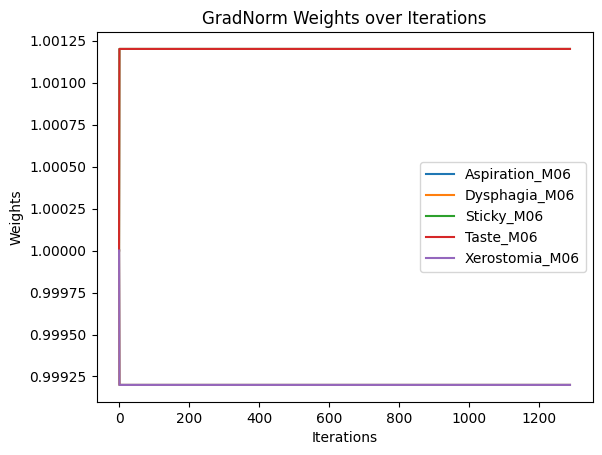

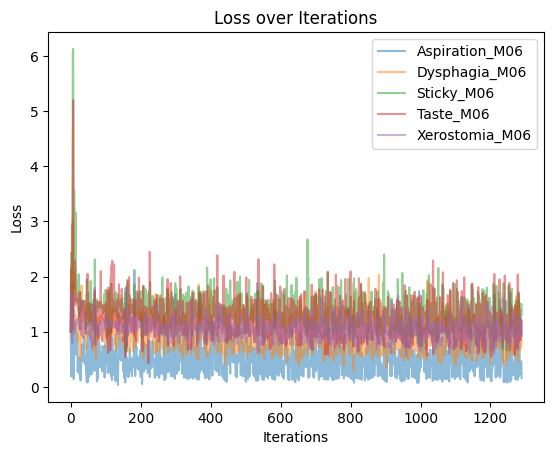

In [ ]:
log_weights = np.array(log_weights)
import matplotlib.pyplot as plt
labels = config['columns']['labels']

plt.plot(log_weights, label=labels)

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Weights')
plt.title('GradNorm Weights over Iterations')
plt.show()


log_loss = np.array(log_loss)
plt.plot(log_loss, label=labels, alpha=0.5)

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss over Iterations')
plt.show()

In [ ]:
metric_dict

NameError: name 'metric_dict' is not defined

In [ ]:
model.output_head.linear_layers.shared_fc_layers

ModuleList(
  (0): Dropout(p=0.1, inplace=False)
  (1): Linear(in_features=529, out_features=256, bias=True)
  (2): LeakyReLU(negative_slope=0.1)
)

In [11]:

def validate_gradNorm(config, model, loss_function, val_loader, metric_handler):
    """
    Evaluate the model on the given dataloader.
    
    Returns:
      avg_loss: average loss over the dataloader
      auc_dict: dictionary of AUC values for each label
      preds_dict: dictionary of predictions for each label
      labels_dict: dictionary of true labels for each label
      patientIDs_list: list of patient IDs in the dataloader
    """
    model.eval()

    total_loss = 0.0
    num_batches = 0
    labels = config['columns']['labels']

    sigmoid_act = torch.nn.Sigmoid()
    
    patientIDs_list = []
    preds_dict = dict.fromkeys(labels)
    labels_dict = dict.fromkeys(labels)
    
    for label in labels:
        preds_dict[label] = []
        labels_dict[label] = []

    
    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            logging.debug(f'Validation batch {i}')
            inputs, clinical_features, targets = move_batch_to_device(batch, DEVICE)

            outputs = model(x=inputs, features=clinical_features)
            loss_dict = loss_function(outputs, targets, return_dict=True)

            mean_loss = torch.stack([loss_dict[label] for label in labels]).mean()


            total_loss += mean_loss.item()            
            
            for lab_indx, label in enumerate(labels):
                preds_dict[label] = preds_dict[label] + list(sigmoid_act(outputs[label]).cpu().detach().numpy().reshape((1,targets[:,lab_indx].shape[0]))[0])
                labels_dict[label] = labels_dict[label] + list(targets[:,lab_indx].cpu().detach().numpy().reshape((1,targets[:,lab_indx].shape[0]))[0])
            
            num_batches += 1
            patientIDs_list += list(batch['patient_id'])

    mean_metric_value, metric_dict = metric_handler.calculate_metric(preds_dict, labels_dict)

    avg_loss = total_loss / num_batches

    logging.debug(f'Validation loss: {avg_loss}')

    return avg_loss, loss_dict, mean_metric_value, metric_dict, preds_dict, labels_dict, patientIDs_list